# MWE 41 - DRP-317 Berea map-resistor and FEM micro-continuum comparison

This notebook compares DRP-317 Berea permeability estimates on a scanned
`500 x 500 x 500` ROI with a `30^3` coefficient map:

- optional extracted PNM rows from notebook 42 when its same-ROI PNM output exists
- a 3-D cell-centered TPFA Darcy-Darcy solve on a Kozeny-Carman map
- FEniCSx USFEM Darcy-Brinkman micro-continuum solves from `voids.fem`
- the experimental Berea reference `Kabs = 121 mD`

Direct-image LBM DNS is intentionally not included in this Berea-only CPU
notebook. The direct-image same-ROI comparison is kept in notebook 42.

Scientific scope and assumptions:

- the RAW binary convention is `0 = void/pore`, `1 = solid`
- the porosity map is a target-shape average of the binary ROI
- the permeability map is a Kozeny-Carman closure field, not a direct
  pore-scale measurement
- Darcy-Brinkman FEM uses both porosity and permeability maps

In [1]:
from __future__ import annotations

# ruff: noqa: E402

import json
import os
import time
from itertools import product
from pathlib import Path
from typing import Any

FEM_THREAD_ENV_DEFAULTS = {
    "OMP_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "VECLIB_MAXIMUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
    "NUMEXPR_NUM_THREADS": "1",
}
for name, value in FEM_THREAD_ENV_DEFAULTS.items():
    os.environ.setdefault(name, value)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.image.porosity import (
    load_permeability_map_hdf5,
    load_porosity_map_hdf5,
    permeability_map_from_porosity,
    porosity_map_from_binary_target_shape,
    save_permeability_map_hdf5,
    save_porosity_map_hdf5,
)
from voids.fem.singlephase import (
    FEMMapProblem,
    FEniCSSolverOptions,
    solve_brinkman_usfem,
)
from voids.fvm.singlephase import solve_tpfa
from voids.paths import data_path, project_root

plt.ioff()

In [2]:
# User-editable inputs
sample_name = "DRP-317 Berea"
sample_stem = "Berea_2d25um"
raw_relpath = Path("drp-317") / "Berea_2d25um_binary.raw"
voxel_size_um = 2.25
voxel_size_m = voxel_size_um * 1.0e-6

experimental_porosity_pct = 18.96
experimental_kabs_mD = 121.0
experimental_kabs_rel_error = 0.10

full_shape = (1000, 1000, 1000)
roi_shape = (500, 500, 500)
map_target_shape = (30, 30, 30)
roi_scan_positions = 5
roi_porosity_target = "full_image"  # "full_image" or "experimental"

kozeny_constant = 180.0
solid_permeability_m2 = 1.0e-20
free_flow_permeability_m2 = 1.0e-8
max_permeability_m2 = 1.0e-8

mu_pa_s = 1.0e-3
pressure_inlet_pa = 1.0
pressure_outlet_pa = 0.0
flow_axes = ("x", "y", "z")
resistor_solver_method = "cg"
resistor_solver_parameters: dict[str, Any] = {
    "rtol": 1.0e-10,
    "atol": 0.0,
    "maxiter": 2000,
    "preconditioner": "pyamg",
    "pyamg_solver": "smoothed_aggregation",
}

run_fem = True
fem_porosity_floor = 1.0e-3
fem_k_floor = 1.0e-20
fem_solver_backend = "nvmath_cudss_hybrid_float64"
fem_cudss_hybrid_device_memory_limit = 20_000_000_000
fem_options = FEniCSSolverOptions.nvmath_cudss_direct(
    dtype="float64",
    device_ids=0,
    ir_steps=5,
    use_matching=True,
    host_nthreads=8,
    threading_lib="auto",
    hybrid_mode=True,
    hybrid_device_memory_limit=fem_cudss_hybrid_device_memory_limit,
    use_cuda_register_memory=True,
    check_residual=True,
)
fem_solver_options_metadata = {
    "linear_backend": fem_options.linear_backend,
    "solver_preset": fem_options.solver_preset,
    "linear_system_dtype": fem_options.linear_system_dtype,
    "nvmath_cudss_controls": fem_options.nvmath_cudss_controls,
}

input_dir = data_path() / "drp-317"
pnm_directional_path = (
    project_root()
    / "notebooks"
    / "outputs"
    / "42_mwe_drp317_berea_roi500_map30_same_roi_comparison"
    / "drp317_berea_roi500_map30_same_roi_pnm_directional.csv"
)

output_dir = (
    project_root()
    / "notebooks"
    / "outputs"
    / "41_mwe_drp317_berea_map_resistor_micro_continuum"
)
output_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "drp317_berea_roi500_map30"

M2_PER_MD = 9.869233e-16

## Load the Berea ROI

In [3]:
raw_path = data_path() / raw_relpath
if not raw_path.exists():
    raise FileNotFoundError(f"Missing DRP-317 Berea RAW file: {raw_path}")

expected_voxels = int(np.prod(np.asarray(full_shape, dtype=np.int64)))
actual_voxels = raw_path.stat().st_size // np.dtype(np.uint8).itemsize
if actual_voxels != expected_voxels:
    raise ValueError(
        f"Configured shape {full_shape} requires {expected_voxels:,} voxels, "
        f"but {raw_path.name} stores {actual_voxels:,}."
    )

raw_image = np.memmap(raw_path, dtype=np.uint8, mode="r", shape=full_shape, order="C")


def raw_to_void(raw: np.ndarray) -> np.ndarray:
    """Return the DRP-317 Berea phase convention used in notebook 18."""

    return np.asarray(raw == 0, dtype=bool)


def candidate_starts(full_edge: int, sub_edge: int, *, count: int) -> list[int]:
    if sub_edge > full_edge:
        raise ValueError(f"ROI edge {sub_edge} exceeds full edge {full_edge}")
    if count <= 1 or sub_edge == full_edge:
        return [0]
    max_origin = full_edge - sub_edge
    return sorted({int(round(value)) for value in np.linspace(0, max_origin, count)})


phi_void_is_zero = 1.0 - float(np.mean(raw_image))
target_porosity = (
    phi_void_is_zero
    if roi_porosity_target == "full_image"
    else 0.01 * experimental_porosity_pct
)

scan_records: list[dict[str, object]] = []
starts_by_axis = [
    candidate_starts(full, sub, count=roi_scan_positions)
    for full, sub in zip(full_shape, roi_shape, strict=True)
]
for origin in product(*starts_by_axis):
    slices = tuple(
        slice(start, start + size)
        for start, size in zip(origin, roi_shape, strict=True)
    )
    block_raw = np.asarray(raw_image[slices], dtype=np.uint8)
    block_porosity = float(raw_to_void(block_raw).mean())
    scan_records.append(
        {
            "origin": tuple(int(value) for value in origin),
            "porosity_pct": 100.0 * block_porosity,
            "target_porosity_pct": 100.0 * target_porosity,
            "abs_porosity_error_pct_points": 100.0
            * abs(block_porosity - target_porosity),
        }
    )

roi_scan = pd.DataFrame(scan_records).sort_values(
    ["abs_porosity_error_pct_points", "porosity_pct"],
    kind="stable",
)
roi_scan = roi_scan.reset_index(drop=True)
roi_origin = tuple(int(value) for value in roi_scan.loc[0, "origin"])
roi_stop = tuple(o + s for o, s in zip(roi_origin, roi_shape, strict=True))
roi_slices = tuple(slice(o, stop) for o, stop in zip(roi_origin, roi_stop, strict=True))
roi_raw = np.asarray(raw_image[roi_slices], dtype=np.uint8)
values, counts = np.unique(roi_raw, return_counts=True)
unexpected_values = set(values.tolist()) - {0, 1}
if unexpected_values:
    raise ValueError(f"Expected binary RAW values 0/1; got {sorted(values.tolist())}")

void_roi = raw_to_void(roi_raw)
roi_porosity_pct = 100.0 * float(void_roi.mean())

phase_summary = pd.DataFrame(
    {
        "raw_value": values.astype(int),
        "voxel_count": counts.astype(np.int64),
        "fraction": counts / counts.sum(),
        "phase": ["void/pore" if int(value) == 0 else "solid" for value in values],
    }
)
roi_summary = pd.DataFrame(
    [
        {"quantity": "sample", "value": sample_name, "units": "-"},
        {"quantity": "RAW path", "value": str(raw_path), "units": "-"},
        {"quantity": "ROI origin", "value": str(roi_origin), "units": "voxels"},
        {"quantity": "ROI shape", "value": str(roi_shape), "units": "voxels"},
        {"quantity": "voxel size", "value": voxel_size_m, "units": "m"},
        {"quantity": "ROI porosity", "value": roi_porosity_pct, "units": "%"},
        {
            "quantity": "experimental porosity",
            "value": experimental_porosity_pct,
            "units": "%",
        },
        {"quantity": "experimental Kabs", "value": experimental_kabs_mD, "units": "mD"},
        {
            "quantity": "map target shape",
            "value": str(map_target_shape),
            "units": "cells",
        },
    ]
)

display(roi_scan.head(10))
display(phase_summary)
display(roi_summary)

,origin,porosity_pct,target_porosity_pct,abs_porosity_error_pct_points
0,"(500, 500, 250)",21.674083,21.671533,0.002550
1,"(0, 250, 250)",21.675891,21.671533,0.004358
2,"(375, 500, 250)",21.687204,21.671533,0.015671
3,"(375, 375, 125)",21.694754,21.671533,0.023221
4,"(125, 125, 375)",21.644186,21.671533,0.027347
5,"(0, 500, 250)",21.700926,21.671533,0.029393
6,"(250, 250, 375)",21.702969,21.671533,0.031436
7,"(125, 125, 125)",21.636626,21.671533,0.034907
8,"(125, 500, 125)",21.709042,21.671533,0.037509
9,"(250, 500, 125)",21.730502,21.671533,0.058968


,raw_value,voxel_count,fraction,phase
0,0,27092604,0.216741,void/pore
1,1,97907396,0.783259,solid


,quantity,value,units
0,sample,DRP-317 Berea,-
1,RAW path,/prj/thermophase/volpatto/Work/voids/examples/...,-
2,ROI origin,"(500, 500, 250)",voxels
3,ROI shape,"(500, 500, 500)",voxels
4,voxel size,0.000002,m
5,ROI porosity,21.674083,%
6,experimental porosity,18.96,%
7,experimental Kabs,121.0,mD
8,map target shape,"(30, 30, 30)",cells


PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi500_map30_binary_midplanes.png')

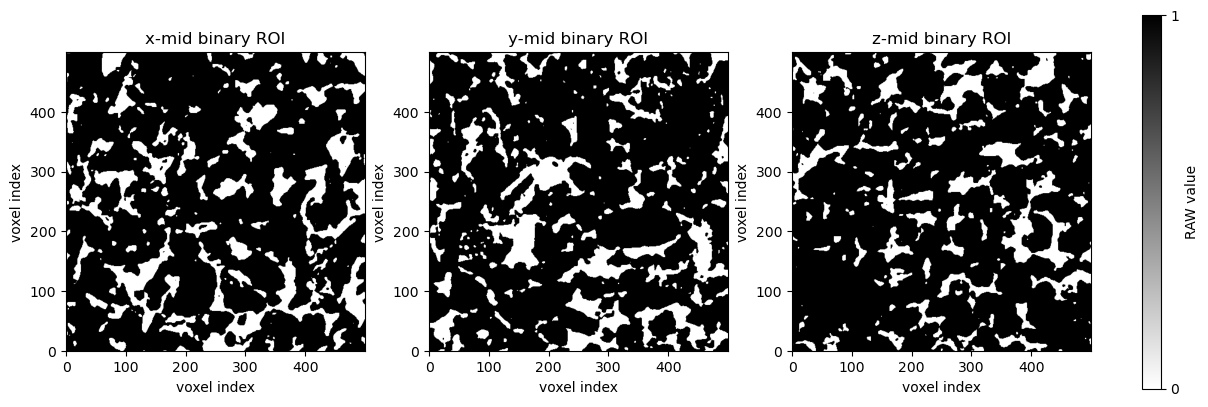

In [4]:
roi_mid = tuple(s // 2 for s in void_roi.shape)
binary_slice_specs = [
    ("x-mid", np.take(roi_raw, roi_mid[0], axis=0)),
    ("y-mid", np.take(roi_raw, roi_mid[1], axis=1)),
    ("z-mid", np.take(roi_raw, roi_mid[2], axis=2)),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), constrained_layout=True)
for ax, (title, binary_slice) in zip(axes, binary_slice_specs, strict=True):
    image = ax.imshow(binary_slice.T, origin="lower", vmin=0, vmax=1, cmap="gray_r")
    ax.set_title(f"{title} binary ROI")
    ax.set_xlabel("voxel index")
    ax.set_ylabel("voxel index")
fig.colorbar(image, ax=axes.ravel().tolist(), ticks=[0, 1], label="RAW value")

binary_figure_path = output_dir / f"{output_prefix}_binary_midplanes.png"
fig.savefig(binary_figure_path, dpi=180)
binary_figure_path

## Build porosity and Kozeny-Carman permeability maps

In [5]:
porosity_map = porosity_map_from_binary_target_shape(
    void_roi,
    target_shape=map_target_shape,
    voxel_size=(voxel_size_m, voxel_size_m, voxel_size_m),
    metadata={
        "case": output_prefix,
        "raw_filename": raw_relpath.name,
        "raw_shape": full_shape,
        "raw_order": "C",
        "roi_origin": roi_origin,
        "roi_shape": roi_shape,
        "map_target_shape": map_target_shape,
        "phase_convention": "0=void_or_pore, 1=solid",
        "experimental_porosity_pct": experimental_porosity_pct,
        "experimental_kabs_mD": experimental_kabs_mD,
    },
)

characteristic_length_m = min(porosity_map.cell_size)
permeability_map = permeability_map_from_porosity(
    porosity_map,
    characteristic_length=characteristic_length_m,
    kozeny_constant=kozeny_constant,
    solid_permeability=solid_permeability_m2,
    free_flow_permeability=free_flow_permeability_m2,
    max_permeability=max_permeability_m2,
    metadata={
        "closure_note": "Kozeny-Carman coefficient map for DRP-317 Berea ROI comparison",
        "scientific_caveat": "closure field, not a direct image-resolved permeability solve",
    },
)

porosity_h5 = output_dir / f"{output_prefix}_porosity_map.h5"
permeability_h5 = output_dir / f"{output_prefix}_permeability_map.h5"
save_porosity_map_hdf5(porosity_map, porosity_h5)
save_permeability_map_hdf5(permeability_map, permeability_h5)

loaded_porosity = load_porosity_map_hdf5(porosity_h5)
loaded_permeability = load_permeability_map_hdf5(permeability_h5)
assert np.allclose(loaded_porosity.values, porosity_map.values)
assert np.allclose(loaded_permeability.values, permeability_map.values)

map_summary = pd.DataFrame(
    [
        {
            "field": "porosity",
            "shape": str(porosity_map.shape),
            "min": float(np.min(porosity_map.values)),
            "mean": float(np.mean(porosity_map.values)),
            "max": float(np.max(porosity_map.values)),
            "units": "-",
        },
        {
            "field": "permeability",
            "shape": str(permeability_map.shape),
            "min": float(np.min(permeability_map.values)),
            "mean": float(np.mean(permeability_map.values)),
            "max": float(np.max(permeability_map.values)),
            "units": "m^2",
        },
    ]
)
display(map_summary)

,field,shape,min,mean,max,units
0,porosity,"(30, 30, 30)",0.000000e+00,2.168835e-01,1.000000e+00,-
1,permeability,"(30, 30, 30)",6.590624e-23,7.066097e-11,1.000000e-08,m^2


PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi500_map30_porosity_permeability_midplanes.png')

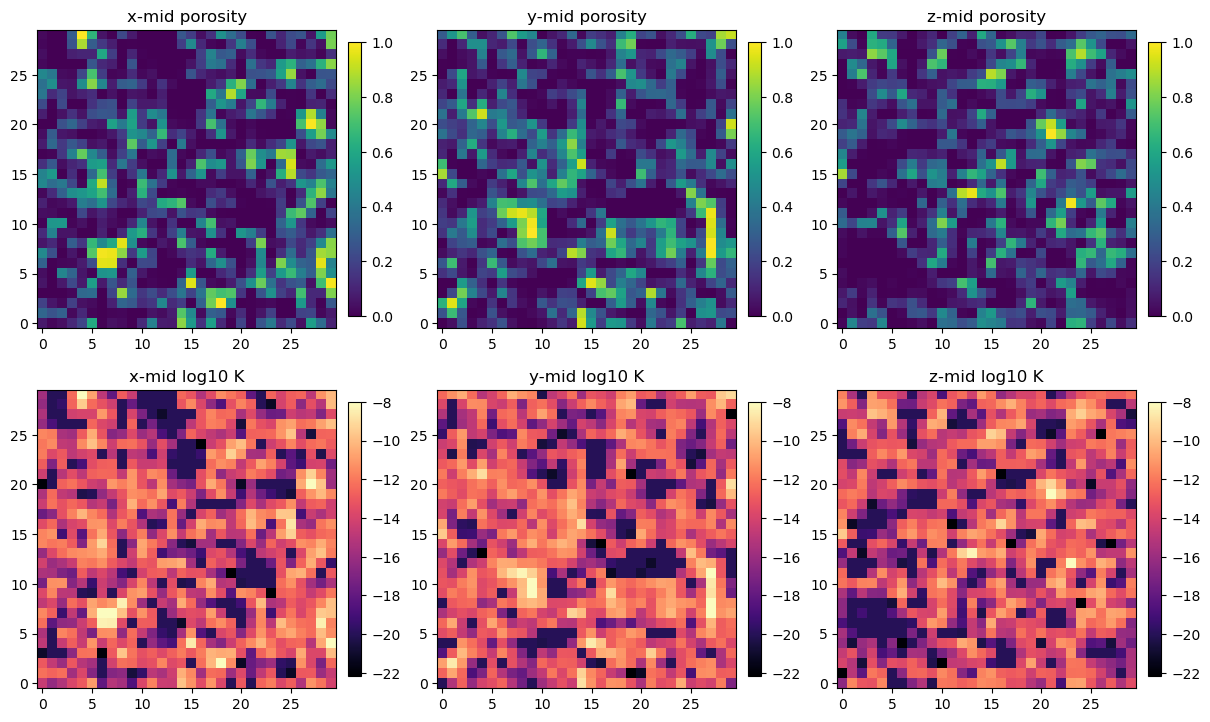

In [6]:
mid = tuple(s // 2 for s in porosity_map.shape)
map_slice_specs = [
    (
        "x-mid",
        np.take(porosity_map.values, mid[0], axis=0),
        np.take(permeability_map.values, mid[0], axis=0),
    ),
    (
        "y-mid",
        np.take(porosity_map.values, mid[1], axis=1),
        np.take(permeability_map.values, mid[1], axis=1),
    ),
    (
        "z-mid",
        np.take(porosity_map.values, mid[2], axis=2),
        np.take(permeability_map.values, mid[2], axis=2),
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7.2), constrained_layout=True)
finite_log = np.log10(permeability_map.values[np.isfinite(permeability_map.values)])
for col, (title, porosity_slice, permeability_slice) in enumerate(map_slice_specs):
    im0 = axes[0, col].imshow(
        porosity_slice.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis"
    )
    axes[0, col].set_title(f"{title} porosity")
    fig.colorbar(im0, ax=axes[0, col], fraction=0.046, pad=0.04)

    with np.errstate(divide="ignore"):
        log_perm = np.log10(permeability_slice)
    im1 = axes[1, col].imshow(
        log_perm.T,
        origin="lower",
        vmin=float(np.min(finite_log)),
        vmax=float(np.max(finite_log)),
        cmap="magma",
    )
    axes[1, col].set_title(f"{title} log10 K")
    fig.colorbar(im1, ax=axes[1, col], fraction=0.046, pad=0.04)

map_figure_path = output_dir / f"{output_prefix}_porosity_permeability_midplanes.png"
fig.savefig(map_figure_path, dpi=180)
map_figure_path

## Cell-centered 3-D TPFA Darcy-Darcy solve

In [7]:
resistor_results = {
    axis: solve_tpfa(
        permeability_map,
        flow_axis=axis,
        viscosity=mu_pa_s,
        pressure_inlet=pressure_inlet_pa,
        pressure_outlet=pressure_outlet_pa,
        solver_method=resistor_solver_method,
        solver_parameters=resistor_solver_parameters,
    )
    for axis in flow_axes
}

resistor_df = pd.DataFrame(
    [
        {
            "family": "map_resistor",
            "formulation": "darcy_darcy_tpfa_fv",
            "method": "TPFA finite-volume Darcy-Darcy",
            "axis": result.flow_axis,
            "mu_Pa_s": mu_pa_s,
            "pressure_inlet_Pa": pressure_inlet_pa,
            "pressure_outlet_Pa": pressure_outlet_pa,
            "delta_p_Pa": abs(pressure_inlet_pa - pressure_outlet_pa),
            "inlet_flux_m3_s": result.inlet_flow_rate,
            "outlet_flux_m3_s": result.outlet_flow_rate,
            "mass_imbalance_relative": result.mass_balance_error,
            "K_eq_m2": result.permeability,
            "K_eq_mD": result.permeability / M2_PER_MD,
            "matrix_nnz": result.matrix_nnz,
            "solve_seconds": result.solve_seconds,
            "solver_backend": (
                f"{result.solver_method}+{result.solver_info['preconditioner']}"
                if "preconditioner" in result.solver_info
                else result.solver_method
            ),
            "linear_residual_relative": result.residual_relative,
            "solver_info_json": json.dumps(result.solver_info, sort_keys=True),
        }
        for result in resistor_results.values()
    ]
)
display(resistor_df)

,family,formulation,method,axis,mu_Pa_s,pressure_inlet_Pa,pressure_outlet_Pa,delta_p_Pa,inlet_flux_m3_s,outlet_flux_m3_s,mass_imbalance_relative,K_eq_m2,K_eq_mD,matrix_nnz,solve_seconds,solver_backend,linear_residual_relative,solver_info_json
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,x,0.001,1.0,0.0,1.0,2.344616e-13,2.344616e-13,1.210809e-08,2.084103e-13,211.171699,183600,0.551981,cg+pyamg,8.691589e-11,"{""info"": 0, ""linear_system_dtype"": ""float64"", ..."
1,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,y,0.001,1.0,0.0,1.0,2.151466e-13,2.151466e-13,2.523541e-09,1.912415e-13,193.775401,183600,0.576999,cg+pyamg,8.918997e-11,"{""info"": 0, ""linear_system_dtype"": ""float64"", ..."
2,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,z,0.001,1.0,0.0,1.0,1.992373e-13,1.992373e-13,5.733769e-08,1.770998e-13,179.446355,183600,0.504770,cg+pyamg,8.255026e-11,"{""info"": 0, ""linear_system_dtype"": ""float64"", ..."


## FEniCSx USFEM micro-continuum solves

In [8]:
fem_output_dir = output_dir / "fenicsx_usfem_micro_continuum"
fem_output_dir.mkdir(parents=True, exist_ok=True)
fem_directional_path = fem_output_dir / f"{output_prefix}_fenicsx_usfem_directional.csv"
fem_directional_paths = [fem_directional_path]
fem_status_path = output_dir / f"{output_prefix}_fem_status.json"

fem_status: dict[str, Any] = {
    "requested": bool(run_fem),
    "backend": "voids.fem.singlephase.solve_brinkman_usfem",
    "solver_backend": fem_solver_backend,
    "solver_options": fem_solver_options_metadata,
    "runs": [],
    "status": "not_requested" if not run_fem else "pending",
}

if run_fem:
    fem_problem = FEMMapProblem(
        permeability_map=permeability_map,
        porosity_map=porosity_map,
        viscosity=mu_pa_s,
        porosity_floor=fem_porosity_floor,
        permeability_floor=fem_k_floor,
    )
    fem_rows: list[dict[str, object]] = []
    fem_status["status"] = "ok"
    for axis in flow_axes:
        start = time.perf_counter()
        result = solve_brinkman_usfem(
            fem_problem,
            flow_axis=axis,
            pressure_inlet=pressure_inlet_pa,
            pressure_outlet=pressure_outlet_pa,
            options=fem_options,
            nondimensional=True,
        )
        wall_seconds = time.perf_counter() - start
        fem_status["runs"].append(
            {
                "axis": axis,
                "status": "ok",
                "solve_seconds": result.solve_seconds,
                "wall_seconds": wall_seconds,
            }
        )
        fem_rows.append(
            {
                "family": "fem_micro_continuum",
                "formulation": result.formulation,
                "method": result.method,
                "solver_backend": f"fenicsx:petsc-lu-{fem_solver_backend}",
                "axis": result.flow_axis,
                "mu_Pa_s": mu_pa_s,
                "pressure_inlet_Pa": result.pressure_inlet,
                "pressure_outlet_Pa": result.pressure_outlet,
                "delta_p_Pa": result.pressure_drop,
                "outlet_flux_m3_s": result.flow_rate,
                "K_eq_m2": result.permeability,
                "K_eq_mD": result.permeability / M2_PER_MD,
                "solve_seconds": result.solve_seconds,
                "wall_seconds": wall_seconds,
                "solver_options_json": json.dumps(
                    fem_solver_options_metadata, sort_keys=True
                ),
                "metadata_json": json.dumps(result.metadata, sort_keys=True),
            }
        )
    fem_df = pd.DataFrame(fem_rows)
    fem_df.to_csv(fem_directional_path, index=False)
    fem_status_path.write_text(json.dumps(fem_status, indent=2), encoding="utf-8")
elif fem_directional_path.exists():
    fem_df = pd.read_csv(fem_directional_path)
    fem_status["status"] = "loaded_existing"
else:
    fem_df = pd.DataFrame()

fem_status

{'requested': True,
 'backend': 'voids.fem.singlephase.solve_brinkman_usfem',
 'solver_backend': 'nvmath_cudss_hybrid_float64',
 'solver_options': {'linear_backend': 'nvmath_cudss',
  'solver_preset': 'direct_reference',
  'linear_system_dtype': 'float64',
  'nvmath_cudss_controls': {'dtype': 'float64',
   'ir_steps': 5,
   'use_matching': True,
   'check_residual': True,
   'device_ids': (0,),
   'host_nthreads': 8,
   'threading_lib': 'auto',
   'hybrid_mode': True,
   'hybrid_device_memory_limit': 20000000000,
   'use_cuda_register_memory': True,
   'residual_rtol': 1e-08}},
 'runs': [{'axis': 'x',
   'status': 'ok',
   'solve_seconds': 200.89390699006617,
   'wall_seconds': 203.37226052803453},
  {'axis': 'y',
   'status': 'ok',
   'solve_seconds': 197.24957440199796,
   'wall_seconds': 198.76952219894156},
  {'axis': 'z',
   'status': 'ok',
   'solve_seconds': 197.66166735999286,
   'wall_seconds': 199.1873171919724}],
 'status': 'ok'}

In [9]:
display(fem_df)

,family,formulation,method,solver_backend,axis,mu_Pa_s,pressure_inlet_Pa,pressure_outlet_Pa,delta_p_Pa,outlet_flux_m3_s,K_eq_m2,K_eq_mD,solve_seconds,wall_seconds,solver_options_json,metadata_json
0,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-nvmath_cudss_hybrid_float64,x,0.001,1.0,0.0,1.0,5.735802e-14,5.098491e-14,51.660456,200.893907,203.372261,"{""linear_backend"": ""nvmath_cudss"", ""linear_sys...","{""alpha_edge"": 1.0, ""linear_backend"": ""nvmath_..."
1,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-nvmath_cudss_hybrid_float64,y,0.001,1.0,0.0,1.0,5.144984e-14,4.573319e-14,46.339158,197.249574,198.769522,"{""linear_backend"": ""nvmath_cudss"", ""linear_sys...","{""alpha_edge"": 1.0, ""linear_backend"": ""nvmath_..."
2,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-nvmath_cudss_hybrid_float64,z,0.001,1.0,0.0,1.0,4.808796e-14,4.274485e-14,43.311219,197.661667,199.187317,"{""linear_backend"": ""nvmath_cudss"", ""linear_sys...","{""alpha_edge"": 1.0, ""linear_backend"": ""nvmath_..."


## Compare PNM, resistor, FEM, and experiment

In [10]:
comparison_rows: list[dict[str, object]] = []


for row in resistor_df.to_dict(orient="records"):
    comparison_rows.append(
        {
            "family": row["family"],
            "formulation": row["formulation"],
            "method": row["method"],
            "solver_backend": "",
            "axis": row["axis"],
            "K_m2": float(row["K_eq_m2"]),
            "K_mD": float(row["K_eq_mD"]),
            "solve_seconds": float(row["solve_seconds"]),
        }
    )

if not fem_df.empty:
    for row in fem_df.to_dict(orient="records"):
        comparison_rows.append(
            {
                "family": row["family"],
                "formulation": row["formulation"],
                "method": row["method"],
                "solver_backend": row.get("solver_backend", ""),
                "axis": row["axis"],
                "K_m2": float(row["K_eq_m2"]),
                "K_mD": float(row["K_eq_mD"]),
                "solve_seconds": float(row["solve_seconds"]),
            }
        )

if pnm_directional_path.exists():
    pnm_directional = pd.read_csv(pnm_directional_path)
    for row in pnm_directional.to_dict(orient="records"):
        method = row.get("method", row.get("backend_label", "PNM"))
        k_m2 = row.get("K_eq_m2", row.get("k_m2", np.nan))
        k_mD = row.get("K_eq_mD", row.get("k_mD", np.nan))
        comparison_rows.append(
            {
                "family": "extracted_pnm",
                "formulation": "pore_network_model",
                "method": method,
                "solver_backend": "",
                "axis": row["axis"],
                "K_m2": float(k_m2),
                "K_mD": float(k_mD),
                "solve_seconds": np.nan,
            }
        )
else:
    pnm_directional = pd.DataFrame()
    print(f"PNM directional summary not found: {pnm_directional_path}")

for axis in flow_axes:
    comparison_rows.append(
        {
            "family": "experimental",
            "formulation": "bulk_experiment",
            "method": "Experimental Kabs",
            "solver_backend": "",
            "axis": axis,
            "K_m2": experimental_kabs_mD * M2_PER_MD,
            "K_mD": experimental_kabs_mD,
            "solve_seconds": np.nan,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(["axis", "family", "method"]))

,family,formulation,method,solver_backend,axis,K_m2,K_mD,solve_seconds
6,experimental,bulk_experiment,Experimental Kabs,,x,1.194177e-13,121.000000,NaN
3,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-nvmath_cudss_hybrid_float64,x,5.098491e-14,51.660456,200.893907
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,,x,2.084103e-13,211.171699,0.551981
7,experimental,bulk_experiment,Experimental Kabs,,y,1.194177e-13,121.000000,NaN
4,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-nvmath_cudss_hybrid_float64,y,4.573319e-14,46.339158,197.249574
1,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,,y,1.912415e-13,193.775401,0.576999
8,experimental,bulk_experiment,Experimental Kabs,,z,1.194177e-13,121.000000,NaN
5,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-nvmath_cudss_hybrid_float64,z,4.274485e-14,43.311219,197.661667
2,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,,z,1.770998e-13,179.446355,0.504770


In [11]:
ratio_rows: list[dict[str, object]] = []
for _, row in comparison_df.iterrows():
    k_row = float(row["K_mD"])
    ratio_rows.append(
        {
            "axis": row["axis"],
            "family": row["family"],
            "method": row["method"],
            "K_method_mD": k_row,
            "K_experimental_mD": experimental_kabs_mD,
            "method_over_experiment": k_row / experimental_kabs_mD,
            "experiment_over_method": experimental_kabs_mD / k_row,
        }
    )
ratio_df = pd.DataFrame(ratio_rows)
display(ratio_df.sort_values(["axis", "family", "method"]))

,axis,family,method,K_method_mD,K_experimental_mD,method_over_experiment,experiment_over_method
6,x,experimental,Experimental Kabs,121.000000,121.0,1.000000,1.000000
3,x,fem_micro_continuum,Darcy-Brinkman USFEM CG1 x DG1,51.660456,121.0,0.426946,2.342217
0,x,map_resistor,TPFA finite-volume Darcy-Darcy,211.171699,121.0,1.745221,0.572993
7,y,experimental,Experimental Kabs,121.000000,121.0,1.000000,1.000000
4,y,fem_micro_continuum,Darcy-Brinkman USFEM CG1 x DG1,46.339158,121.0,0.382968,2.611183
1,y,map_resistor,TPFA finite-volume Darcy-Darcy,193.775401,121.0,1.601450,0.624434
8,z,experimental,Experimental Kabs,121.000000,121.0,1.000000,1.000000
5,z,fem_micro_continuum,Darcy-Brinkman USFEM CG1 x DG1,43.311219,121.0,0.357944,2.793733
2,z,map_resistor,TPFA finite-volume Darcy-Darcy,179.446355,121.0,1.483028,0.674296


## Visual diagnostics

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi500_map30_model_comparison.png')

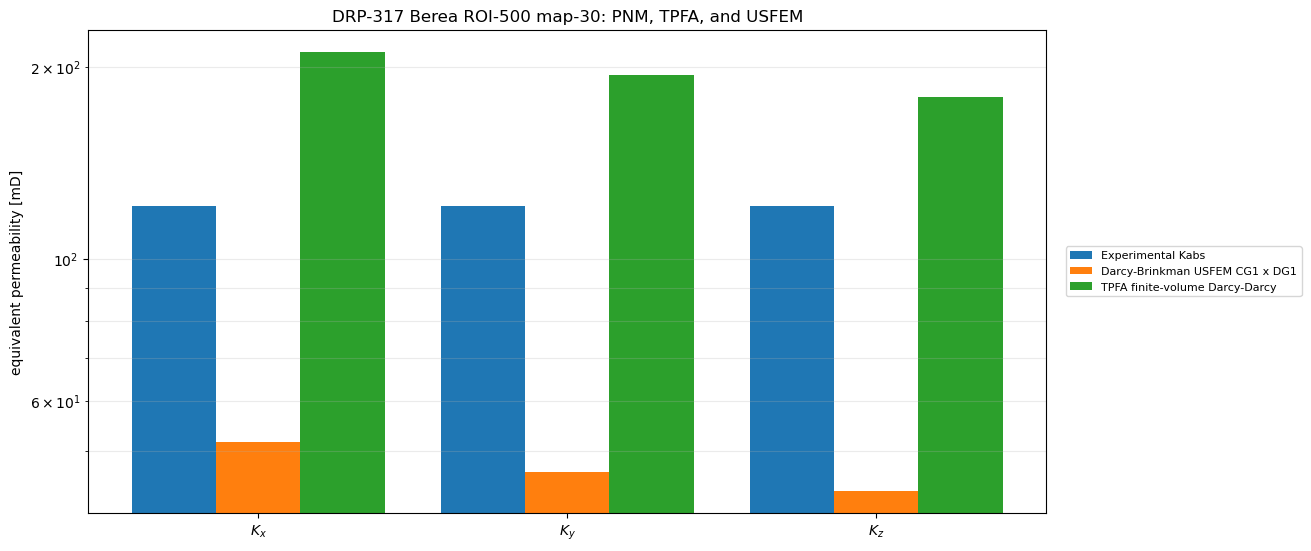

In [12]:
plot_df = comparison_df.copy()
axis_order = ["x", "y", "z"]
method_order = [
    "Experimental Kabs",
    "Darcy-Brinkman USFEM CG1 x DG1",
    "TPFA finite-volume Darcy-Darcy",
    "PoreSpy snow2",
    "PREGO",
    "Native maximal-ball",
]
available_methods = [
    method for method in method_order if method in set(plot_df["method"])
]

fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
bar_width = 0.82 / max(len(available_methods), 1)
x_positions = np.arange(len(axis_order), dtype=float)

for method_index, method in enumerate(available_methods):
    subset = plot_df[plot_df["method"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(float(match.iloc[0]["K_mD"]) if not match.empty else np.nan)
    offset = (method_index - 0.5 * (len(available_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.set_yscale("log")
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("equivalent permeability [mD]")
ax.set_title("DRP-317 Berea ROI-500 map-30: PNM, TPFA, and USFEM")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

comparison_plot_path = output_dir / f"{output_prefix}_model_comparison.png"
fig.savefig(comparison_plot_path, dpi=200)
comparison_plot_path

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi500_map30_model_solve_time.png')

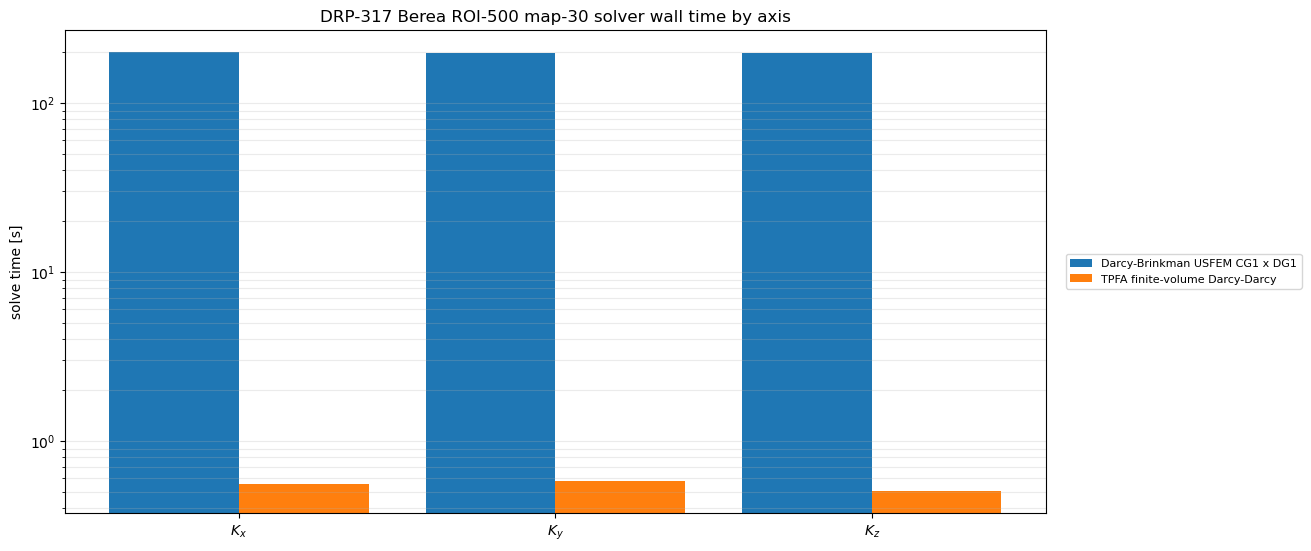

In [13]:
timing_df = plot_df[np.isfinite(plot_df["solve_seconds"])].copy()
available_timing_methods = [
    method for method in method_order if method in set(timing_df["method"])
]

fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
bar_width = 0.82 / max(len(available_timing_methods), 1)

for method_index, method in enumerate(available_timing_methods):
    subset = timing_df[timing_df["method"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(
            float(match.iloc[0]["solve_seconds"]) if not match.empty else np.nan
        )
    offset = (method_index - 0.5 * (len(available_timing_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.set_yscale("log")
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("solve time [s]")
ax.set_title("DRP-317 Berea ROI-500 map-30 solver wall time by axis")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

time_plot_path = output_dir / f"{output_prefix}_model_solve_time.png"
fig.savefig(time_plot_path, dpi=200)
time_plot_path

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi500_map30_model_comparison_heatmap.png')

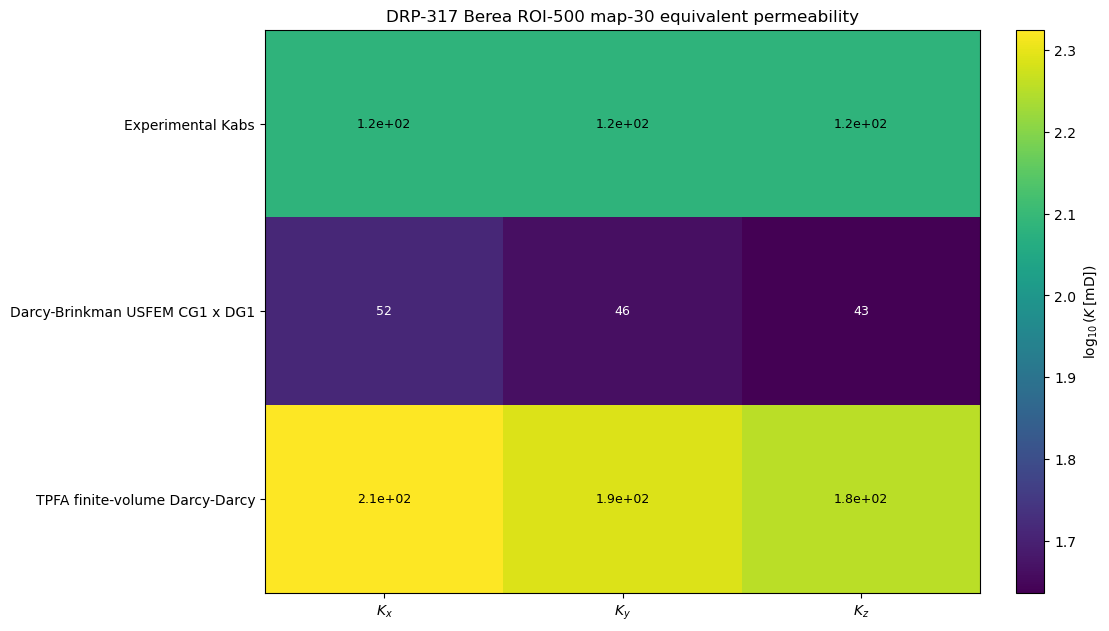

In [14]:
heatmap_df = (
    plot_df.pivot_table(index="method", columns="axis", values="K_mD", aggfunc="first")
    .reindex(available_methods)
    .reindex(columns=axis_order)
)
with np.errstate(divide="ignore", invalid="ignore"):
    heatmap_values = np.log10(heatmap_df.to_numpy(dtype=float))

fig, ax = plt.subplots(figsize=(11, 6.2), constrained_layout=True)
finite_values = heatmap_values[np.isfinite(heatmap_values)]
image = ax.imshow(
    heatmap_values,
    cmap="viridis",
    aspect="auto",
    vmin=float(np.min(finite_values)),
    vmax=float(np.max(finite_values)),
)
ax.set_xticks(np.arange(len(axis_order)))
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("DRP-317 Berea ROI-500 map-30 equivalent permeability")
fig.colorbar(image, ax=ax, label=r"$\log_{10}(K\,[\mathrm{mD}])$")

for row_index, method in enumerate(heatmap_df.index):
    for col_index, axis in enumerate(axis_order):
        value = heatmap_df.loc[method, axis]
        if not np.isfinite(value):
            continue
        ax.text(
            col_index,
            row_index,
            f"{value:.2g}",
            ha="center",
            va="center",
            color=(
                "white"
                if heatmap_values[row_index, col_index] < np.median(finite_values)
                else "black"
            ),
            fontsize=9,
        )

comparison_heatmap_path = output_dir / f"{output_prefix}_model_comparison_heatmap.png"
fig.savefig(comparison_heatmap_path, dpi=200)
comparison_heatmap_path

## Save tables

In [15]:
roi_scan_path = output_dir / f"{output_prefix}_scan.csv"
roi_summary_path = output_dir / f"{output_prefix}_summary.csv"
phase_summary_path = output_dir / f"{output_prefix}_phase_summary.csv"
map_summary_path = output_dir / f"{output_prefix}_map_summary.csv"
resistor_path = output_dir / f"{output_prefix}_map_resistor_directional.csv"
comparison_path = output_dir / f"{output_prefix}_model_comparison.csv"
ratio_path = output_dir / f"{output_prefix}_model_ratios_to_experiment.csv"

roi_scan.to_csv(roi_scan_path, index=False)
roi_summary.to_csv(roi_summary_path, index=False)
phase_summary.to_csv(phase_summary_path, index=False)
map_summary.to_csv(map_summary_path, index=False)
resistor_df.to_csv(resistor_path, index=False)
comparison_df.to_csv(comparison_path, index=False)
ratio_df.to_csv(ratio_path, index=False)
fem_status_path.write_text(json.dumps(fem_status, indent=2), encoding="utf-8")

saved_paths = [
    porosity_h5,
    permeability_h5,
    roi_scan_path,
    roi_summary_path,
    phase_summary_path,
    map_summary_path,
    resistor_path,
    comparison_path,
    ratio_path,
    fem_status_path,
    binary_figure_path,
    map_figure_path,
    comparison_plot_path,
    time_plot_path,
    comparison_heatmap_path,
]
saved_paths.extend(path for path in fem_directional_paths if path.exists())

for axis, result in resistor_results.items():
    pressure_path = output_dir / f"{output_prefix}_map_resistor_pressure_{axis}.npy"
    np.save(pressure_path, result.pressure)
    saved_paths.append(pressure_path)

pd.DataFrame({"saved_path": [str(path) for path in saved_paths]})

,saved_path
0,/prj/thermophase/volpatto/Work/voids/notebooks...
1,/prj/thermophase/volpatto/Work/voids/notebooks...
2,/prj/thermophase/volpatto/Work/voids/notebooks...
3,/prj/thermophase/volpatto/Work/voids/notebooks...
4,/prj/thermophase/volpatto/Work/voids/notebooks...
5,/prj/thermophase/volpatto/Work/voids/notebooks...
6,/prj/thermophase/volpatto/Work/voids/notebooks...
7,/prj/thermophase/volpatto/Work/voids/notebooks...
8,/prj/thermophase/volpatto/Work/voids/notebooks...
9,/prj/thermophase/volpatto/Work/voids/notebooks...


## Interpretation notes

- PNM rows are included only when notebook 42 has already generated same-ROI
  extraction outputs for this `500^3` ROI.
- The Darcy-Brinkman FEM row is the micro-continuum comparison because it uses
  both `phi` and `K(phi)`. The TPFA finite-volume Darcy-Darcy row is a pure
  permeability-coefficient baseline.
- The map-based values are sensitive to `map_target_shape`, the Kozeny-Carman
  characteristic length, and the permeability caps. These parameters are
  closure assumptions, not measured Berea properties.
- Direct-image LBM DNS is left out of this Berea-only CPU notebook. Notebook
  42 owns the direct-image same-ROI comparison.